In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score
from preprocessing import get_features_and_target
from visualizer import plot_visualizer, plot_visualizer_classification
import plotly.graph_objects as go
from sklearn.model_selection import StratifiedKFold
from preprocessing import get_features_and_target_classification
from tabpfn import TabPFNClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from xgboost import XGBRegressor

In [2]:
import huggingface_hub
huggingface_hub.login()

# Getting Dataframe

In [3]:
# Load the training and development datasets
train_df = pd.read_csv("data/train_data.csv")
dev_df = pd.read_csv("data/development_data.csv")
#sc = StandardScaler()

target_column = "Category" 

x_train, y_train = get_features_and_target(train_df, target_column)
x_dev, y_dev = get_features_and_target(dev_df, target_column)

#x_train = sc.fit_transform(X=x_train)
#x_dev = sc.transform(x_dev)


# Defining Model

In [ ]:
#model = 'XGBoost'
model = 'TabPFNClassifier'

# Add Physical Columns Interfacial_Failure and Pullout_Failure

In [4]:
def compute_interfacial_failure(df):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1) 
     f_pull = 1 * (np.pi/4) * (4 * np.sqrt(t))**2 * (0.7 * 365) 
     return np.round(f_pull, 1) 

def compute_pullout_failure(df):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1) 
     f_pull = np.pi * ((4 * np.sqrt(t)) + 2*t)*t*365 
     return np.round(f_pull, 1) 

x_train['Interfacial_Failure'] = compute_interfacial_failure(x_train) 
x_train['Pullout_Failure'] = compute_pullout_failure(x_train) 
x_dev['Interfacial_Failure'] = compute_interfacial_failure(x_dev)
x_dev['Pullout_Failure'] = compute_pullout_failure(x_dev)

In [5]:
x_train.head(50)

,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm),Interfacial_Failure,Pullout_Failure
0,35,200,0,6.82,1081.47,0.922,0.920,2953.9,5988.6
1,35,1500,0,52.25,2014.73,0.920,0.925,2953.9,5988.6
2,95,200,0,16.57,1321.93,0.912,0.924,2928.2,5902.3
3,95,200,0,41.42,1615.83,0.948,0.939,3014.9,6195.6
4,35,1500,0,63.82,1137.29,0.930,0.937,2986.0,6097.2
5,35,200,0,16.47,1083.06,0.932,0.928,2979.5,6075.4
6,35,1500,0,50.62,901.01,0.933,0.929,2982.7,6086.3
7,95,1500,0,129.13,1112.82,0.937,0.927,2976.3,6064.5
8,95,200,0,16.55,1357.87,0.929,0.915,2937.8,5934.6
9,95,1500,0,124.16,1078.29,0.925,0.930,2969.9,6042.8


# Fit Model

In [ ]:
if model == 'TabPFNClassifier':
    # Target value

    classifier = TabPFNClassifier() 

    classifier.fit(x_train,y_train)

    predictions = classifier.predict(x_dev)

# Check Validation Data

In [7]:
#test_x = x_dev.iloc[:50].copy()
#test_x.columns

In [8]:
#feature_names = x_train.columns.tolist()
# Fix: tell SHAP what the model's feature names are 
#classifier.feature_names_in_ = np.array(feature_names)

# Calculate SHAP values
#shap_values = interpretability.shap.get_shap_values(
#    estimator=classifier,
#    test_x=test_x,
#    attribute_names=feature_names,
#    algorithm="permutation",
#)

# Create visualization
#fig = interpretability.shap.plot_shap(shap_values)

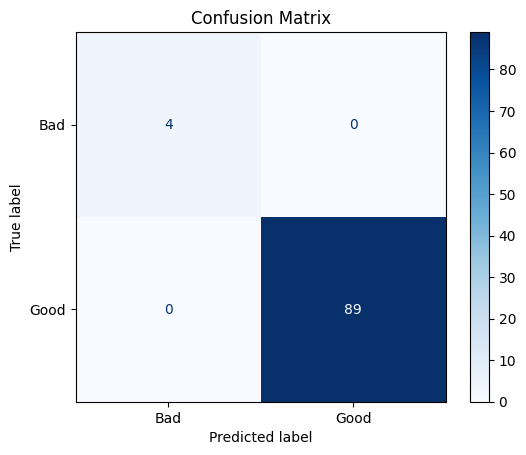

F1 Score: 1.0


In [9]:
# Plot classification
plot_visualizer_classification(
    y_true=y_dev,
    y_pred=predictions,
    class_labels=["Bad", "Good"],
    title=f"Confusion Matrix"
)


# Cross Validation

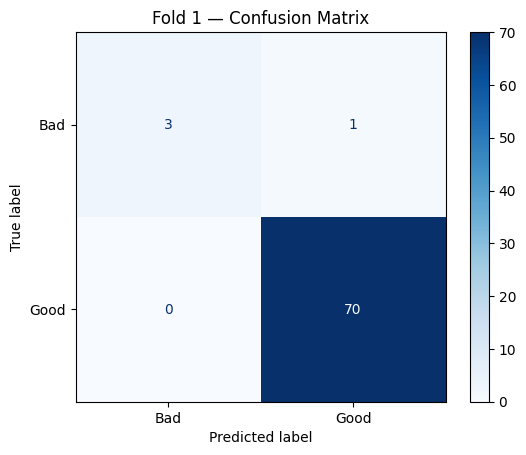

F1 Score: 0.9250253292806484


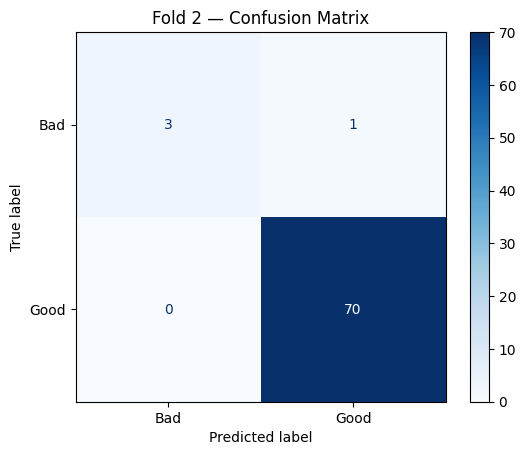

F1 Score: 0.9250253292806484


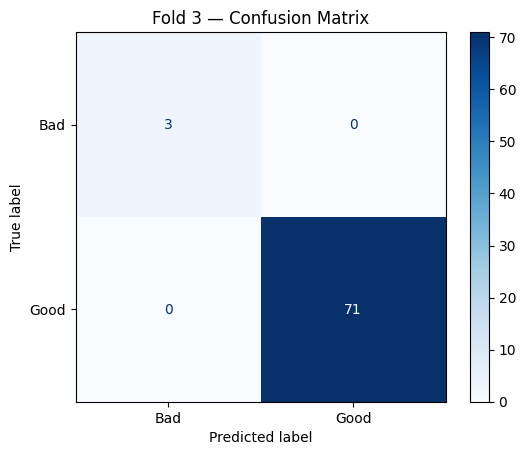

F1 Score: 1.0


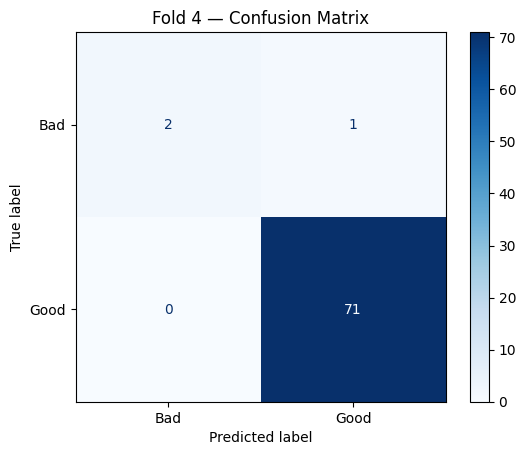

F1 Score: 0.8965034965034966


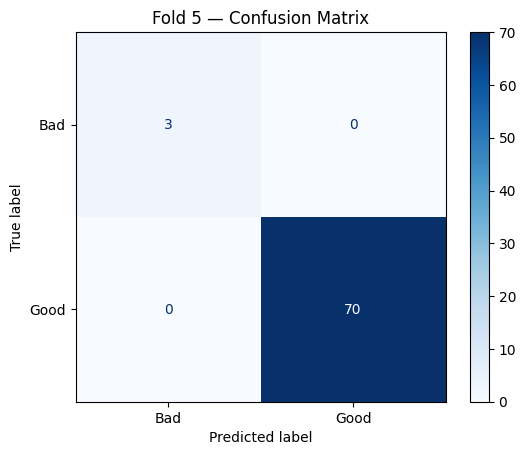

F1 Score: 1.0


In [14]:
cross_df = pd.read_csv("data/train_dev_data.csv")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


mean_list = []

for fold, (train_index, val_index) in enumerate(skf.split(cross_df["Sample ID"], cross_df["Category"])):
    x_tr, y_tr = get_features_and_target(cross_df.iloc[train_index], target_column) 
    x_val, y_val = get_features_and_target(cross_df.iloc[val_index], target_column)

    x_tr['Interfacial_Failure'] = compute_interfacial_failure(x_tr) 
    x_tr['Pullout_Failure'] = compute_pullout_failure(x_tr) 
    x_val['Interfacial_Failure'] = compute_interfacial_failure(x_val)
    x_val['Pullout_Failure'] = compute_pullout_failure(x_val)

    # Predict probabilities (optional)
    prediction_probabilities = classifier.predict_proba(x_val)

    # Predict labels
    predictions = classifier.predict(x_val)

    f1 = f1_score(y_val, predictions, average="macro")
    
    mean_list.append(f1)

    # Plot classification results for this fold
    plot_visualizer_classification(
        y_true=y_val,
        y_pred=predictions,
        class_labels=["Bad", "Good"],
        title=f"Fold {fold+1} — Confusion Matrix"
    )

f1_mean = np.mean(mean_list) 

In [15]:
# Final Evaluation over all Folds

print("F1 Score:", f1_mean)

F1 Score: 0.9493108310129585
